✅ Librairies importées
✅ Modèle chargé
Brier score: 0.1529


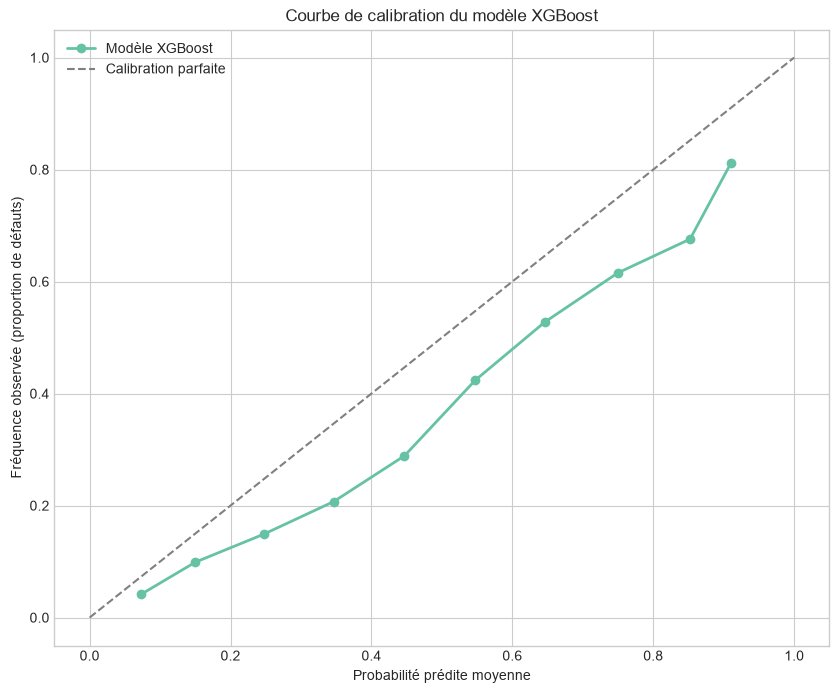


CALIBRATION AVEC PLATT SCALING
Brier score avant calibration: 0.1529
Brier score après calibration: 0.1404


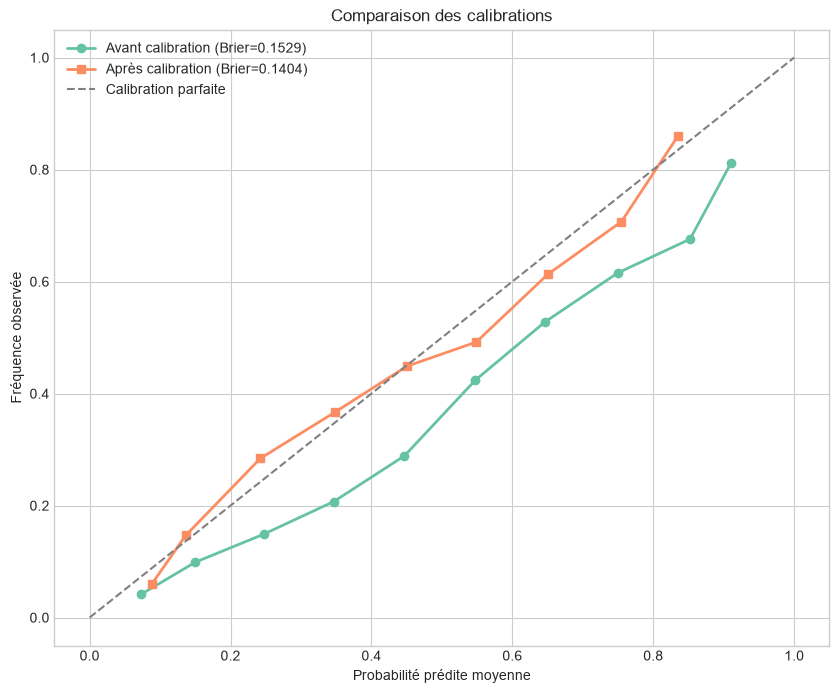

✅ Modèle calibré sauvegardé !
   - Brier score: 0.1404


In [1]:
# %% [markdown]
# # 09 - Calibration du modèle
# ## Projet : AI Credit Risk Prediction Platform

# %% [markdown]
# ### 1. Import des librairies

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Librairies importées")

# %% [markdown]
# ### 2. Chargement des données et du modèle

# %%
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chargement du modèle final
model = joblib.load('../models/xgboost_final_regularized.pkl')
print("✅ Modèle chargé")

# %% [markdown]
# ### 3. Prédictions et probabilités

# %%
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print(f"Brier score: {brier_score_loss(y_test, y_proba):.4f}")

# %% [markdown]
# ### 4. Courbe de calibration

# %%
# Calcul de la calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(10, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modèle XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibration parfaite')
plt.xlabel('Probabilité prédite moyenne')
plt.ylabel('Fréquence observée (proportion de défauts)')
plt.title('Courbe de calibration du modèle XGBoost')
plt.legend()
plt.grid(True)
plt.savefig('../data/processed/calibration_curve.png', dpi=150)
plt.show()

# %% [markdown]
# ### 5. Calibration avec Platt Scaling

# %%
print("\n" + "="*60)
print("CALIBRATION AVEC PLATT SCALING")
print("="*60)

# Calibration
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv=5)
calibrated_model.fit(X_train_scaled, y_train)

# Prédictions calibrées
y_proba_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]

# Brier score après calibration
brier_calibrated = brier_score_loss(y_test, y_proba_calibrated)
print(f"Brier score avant calibration: {brier_score_loss(y_test, y_proba):.4f}")
print(f"Brier score après calibration: {brier_calibrated:.4f}")

# %% [markdown]
# ### 6. Comparaison des calibrations

# %%
# Courbes de calibration
prob_true_orig, prob_pred_orig = calibration_curve(y_test, y_proba, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_calibrated, n_bins=10)

plt.figure(figsize=(10, 8))
plt.plot(prob_pred_orig, prob_true_orig, marker='o', linewidth=2, label='Avant calibration (Brier={:.4f})'.format(brier_score_loss(y_test, y_proba)))
plt.plot(prob_pred_cal, prob_true_cal, marker='s', linewidth=2, label='Après calibration (Brier={:.4f})'.format(brier_calibrated))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibration parfaite')
plt.xlabel('Probabilité prédite moyenne')
plt.ylabel('Fréquence observée')
plt.title('Comparaison des calibrations')
plt.legend()
plt.grid(True)
plt.savefig('../data/processed/calibration_comparison.png', dpi=150)
plt.show()

# %% [markdown]
# ### 7. Sauvegarde du modèle calibré

# %%
joblib.dump(calibrated_model, '../models/xgboost_calibrated.pkl')
print("✅ Modèle calibré sauvegardé !")
print(f"   - Brier score: {brier_calibrated:.4f}")